## Import Libraries  ##

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

## Data Loading ##

In [2]:
CSV_PATH = "AAPL_stock_data.csv"  # update this path if the file is elsewhere

print(f"Loading data from {CSV_PATH}...")

df = pd.read_csv(CSV_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Keep only the columns needed for this notebook
df = df[["Date", "Close"]].dropna().copy()
df.set_index("Date", inplace=True)

print(f"Loaded {len(df)} rows of data.")
print(df.head())

Loading data from AAPL_stock_data.csv...
Loaded 1424 rows of data.
               Close
Date                
2019-01-02  3.378611
2019-01-03  3.174486
2019-01-04  3.377868
2019-01-07  3.556695
2019-01-08  3.468149


## Data Preprocessing ##

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df["Close"].values.reshape(-1, 1))
WINDOW_SIZE = 50  # number of past days to look at

X = []
y = []

for i in range(WINDOW_SIZE, len(scaled_data)):
    X.append(scaled_data[i - WINDOW_SIZE:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))


print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")



X shape: (1374, 50, 1)
y shape: (1374,)

Training samples : 1099
Testing  samples : 275


## Train- Test Split ##

In [ ]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

## Data Visualization (Before Training) ##

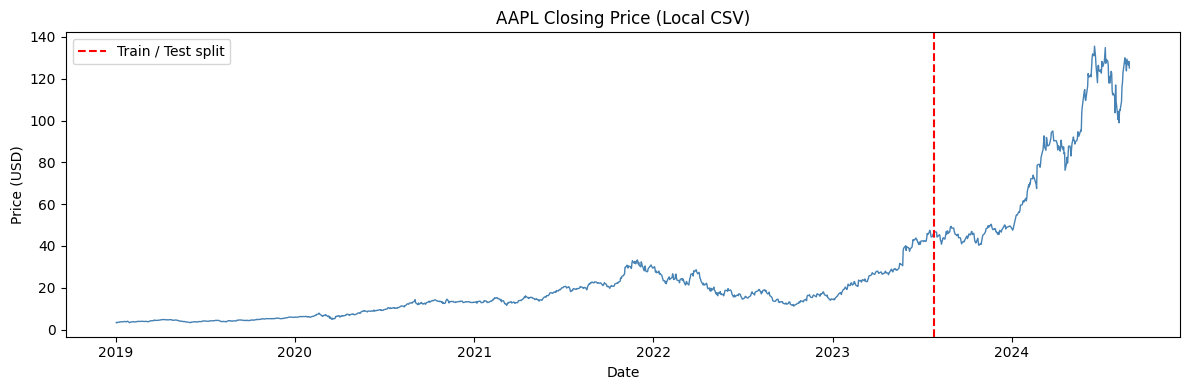


Chart saved to outputs/aapl_price_chart.png

Preprocessing complete! Variables ready: X_train, X_test, y_train, y_test, scaler


In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"], color="steelblue", linewidth=1)
plt.axvline(df.index[split + WINDOW_SIZE], color="red",
            linestyle="--", label="Train / Test split")
plt.title("AAPL Closing Price (Local CSV)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/aapl_price_chart.png", dpi=150)
plt.show()
print("\nChart saved to outputs/aapl_price_chart.png")

print("\nPreprocessing complete! Variables ready: X_train, X_test, y_train, y_test, scaler")

## Model Building (LSTM) + Compile + Training + Predict + Visualization ##

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - loss: 0.0015 - val_loss: 7.5618e-04
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 2.4593e-04 - val_loss: 6.2441e-04
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 1.7244e-04 - val_loss: 6.6180e-04
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 1.6848e-04 - val_loss: 6.0472e-04
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 1.5481e-04 - val_loss: 3.5169e-04
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 1.6503e-04 - val_loss: 7.4759e-04
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 1.6355e-04 - val_loss: 8.4363e-04
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 1.3220e-04 - val_loss: 3.2855e-04
Epoch 9/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 1.2288e-04 - val_loss: 2.7444e-04
Epoch 10/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 1.3034e-04 - val_loss: 2.0432e-04
Epoch 11/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 1.2847e-04 

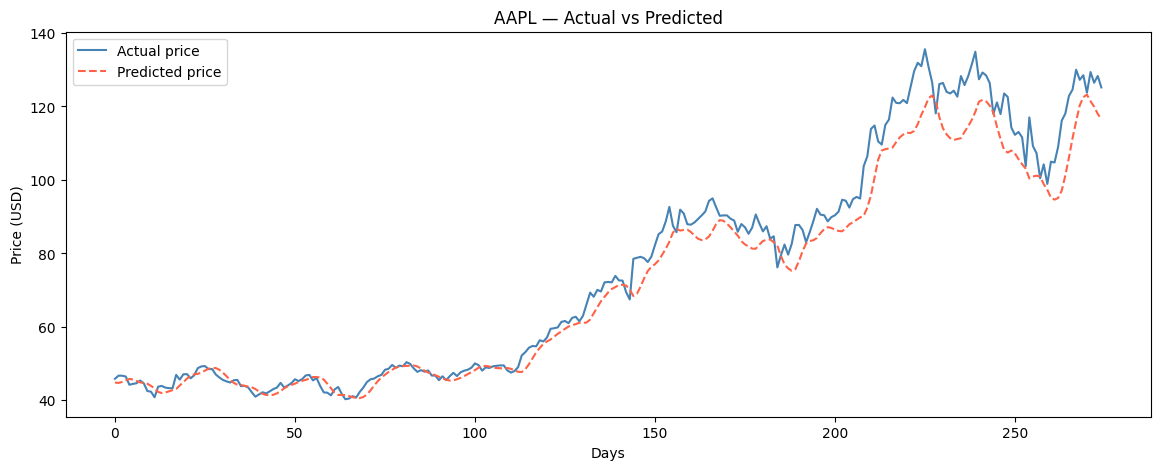


Chart saved to outputs/aapl_loss_chart.png


In [5]:
# ================================================
#  LSTM Stock Price Prediction — AAPL
# ================================================

# ── Part 1: Imports ──────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# ── Part 2: Build Model ──────────────────────────

model=Sequential([
        Input(shape=(WINDOW_SIZE,1)),
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
])

# ── Part 3: Compile ──────────────────────────────
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# ── Part 4: Train ────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Part 5: Predict ──────────────────────────────
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Part 6: Plot ─────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, color='steelblue', label='Actual price')
plt.plot(predictions, color='tomato', linestyle='--', label='Predicted price')
plt.title('AAPL — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.savefig("outputs/aapl_loss_chart.png", dpi=150)
plt.show()
print("\nChart saved to outputs/aapl_loss_chart.png")

## Extract Price  values ##

In [6]:
# Last actual value (previous day)
last_actual = y_test_actual[-1][0]

# Last predicted value (previous day)
last_predicted = predictions[-1][0]

# ---- Next Day Prediction ----
last_window = X_test[-1]  
last_window = last_window.reshape(1, WINDOW_SIZE, 1)

next_pred = model.predict(last_window)
next_pred = scaler.inverse_transform(next_pred)
next_pred_value = next_pred[0][0]

# ---- Print All ----
print("Last Actual Price:", last_actual)
print("Last Predicted Price:", last_predicted)
print("Next Day Predicted Price:", next_pred_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Last Actual Price: 125.175003
Last Predicted Price: 116.570015
Next Day Predicted Price: 116.57002
